## PHẦN 1: KHỞI TẠO & NẠP TÀI NGUYÊN

1/Setup & Load Data
- Nạp bảng Master (master_sales_detail.csv) làm trục phân tích chính.

- Nạp thêm web_traffic và returns từ pre_processed để ráp nối tính toán 2 KPI cốt lõi: Conversion Rate và Return Rate.

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Thiết lập đường dẫn tương đối
MASTER_DIR = "../data/processed/master"
PRE_DIR = "../data/processed/pre_processed"
FIG_DIR = "../output/figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [121]:
# Nạp bảng Master Sales (Trục xương sống)
df_master = pd.read_csv(os.path.join(MASTER_DIR, "master_sales_detail.csv"))

# Nạp bảng Traffic và Returns để tính KPI hệ thống
df_web = pd.read_csv(os.path.join(PRE_DIR, "web_traffic_preprocessed.csv"))
df_returns = pd.read_csv(os.path.join(PRE_DIR, "returns_preprocessed.csv"))

## PHẦN 2: THỐNG KÊ MÔ TẢ TỔNG QUAN (MỚI BỔ SUNG - Tiêu chí: Data Understanding)


1/Thống kê Mô tả Tổng quan (Data Overview)
- Mục đích của phần này: > Trước khi đi sâu vào giải quyết Vấn đề 1, ta cần thực hiện kiểm tra tổng quát tình trạng của tập dữ liệu Master. Đây là bước đệm quan trọng để xây dựng niềm tin vào kết quả phân tích phía sau.

- Phần này xác định điều gì?

    - Quy mô dữ liệu (Data Volume): Xác nhận số lượng dòng/cột để đảm bảo mẫu đủ lớn cho các kết luận thống kê có ý nghĩa.

    - Đặc trưng biến số (Feature Characteristics): Quan sát xu hướng tập trung (Mean, Median) và độ phân tán (Min, Max, STD) của các chỉ số tài chính như Doanh thu, Giá vốn, Số lượng.

- Chức năng của bước này:

    - Kiểm soát chất lượng (Quality Control): Rà soát các giá trị khuyết thiếu (Missing values) hoặc các giá trị bất thường (Outliers) có thể làm sai lệch kết quả.

    - Định hình phân phối: Giúp xác định liệu dữ liệu có bị lệch (skewed) hay không, từ đó lựa chọn phương pháp kiểm định phù hợp ở bước Diagnostic.

- Chứng minh được cái gì?

    - Chứng minh dữ liệu đã được Preprocessing sạch sẽ (không còn Null ở các cột trọng yếu).

    - Chứng minh tính toàn vẹn của dữ liệu: Các giá trị như unit_price hay quantity đều nằm trong khoảng logic dương, sẵn sàng cho việc tính toán KPI.

Kích thước và Tổng quan cấu trúc dữ liệu


In [122]:
print(f"Kích thước bảng Master: {df_master.shape[0]:,} dòng và {df_master.shape[1]} cột.")
print("\nThông tin các cột cơ bản:")
df_master.info()

Kích thước bảng Master: 714,669 dòng và 60 cột.

Thông tin các cột cơ bản:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 60 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   order_id                    714669 non-null  int64  
 1   product_id                  714669 non-null  int64  
 2   quantity                    714669 non-null  int64  
 3   unit_price                  714669 non-null  float64
 4   discount_amount             714669 non-null  float64
 5   promo_id                    714669 non-null  object 
 6   promo_id_2                  714669 non-null  object 
 7   gross_revenue               714669 non-null  float64
 8   net_revenue                 714669 non-null  float64
 9   is_discounted               714669 non-null  int64  
 10  discount_percent            714669 non-null  float64
 11  order_date                  714669 non-null  object 
 1

Thống kê phân phối các biến định lượng (Numerical)

In [123]:
num_cols = ['quantity', 'unit_price', 'discount_amount', 'net_revenue']
# Chọn các cột có tồn tại trong data để tránh lỗi
existing_num_cols = [col for col in num_cols if col in df_master.columns]

print("Thống kê mô tả các biến kinh doanh cốt lõi:")
display(df_master[existing_num_cols].describe().round(2))

Thống kê mô tả các biến kinh doanh cốt lõi:


,quantity,unit_price,discount_amount,net_revenue
count,714669.00,714669.00,714669.00,714669.00
mean,4.50,5114.69,1048.89,21941.44
std,2.29,3774.82,2280.53,21712.28
min,1.00,392.57,0.00,389.74
25%,2.00,1906.89,0.00,6041.64
50%,4.00,4257.77,0.00,14518.07
75%,6.00,7273.76,967.63,30635.50
max,8.00,43056.00,35235.47,331570.40


Kiểm tra dữ liệu khuyết thiếu (Missing Values)


In [124]:
missing_values = df_master.isnull().sum()
print("Số lượng Null tại các cột quan trọng (Nếu có):")
print(missing_values[missing_values > 0])

Số lượng Null tại các cột quan trọng (Nếu có):
shipping_fee              22981
transit_time_days         88654
is_free_shipping          88654
allocated_shipping_fee    22981
dtype: int64


## PHẦN 3: ĐO LƯỜNG SỨC KHỎE HỆ THỐNG (Tiêu chí: Business Metric Mapping)

1.Đo lường KPI Cốt lõi (Vấn đề 1)
- Mục tiêu: Trước khi đi vào chi tiết, ta phải chốt được bức tranh tổng thể bằng 2 KPI mà Đề thi yêu cầu: Conversion Rate (Tỷ lệ chuyển đổi) và Return Rate (Tỷ lệ trả hàng).

- Insight: Nếu Conversion thấp, chứng tỏ Web đang thu hút sai tệp khách hàng (chỉ vào xem) hoặc quá trình checkout có vấn đề.

Tính KPI 1: Conversion Rate (Số đơn / Tổng Sessions)


In [125]:
total_orders = df_master['order_id'].nunique()
total_sessions = df_web['sessions'].sum()
conversion_rate = (total_orders / total_sessions) * 100
print(f"📊 Tỷ lệ chuyển đổi (Conversion Rate): {conversion_rate:.2f}%")

📊 Tỷ lệ chuyển đổi (Conversion Rate): 0.71%


Tính KPI 2: Return Rate (Số lượng trả / Số lượng bán)


In [126]:
total_qty_sold = df_master['quantity'].sum()
total_qty_returned = df_returns['return_quantity'].sum()
return_rate = (total_qty_returned / total_qty_sold) * 100
print(f"📊 Tỷ lệ trả hàng vật lý (Return Rate): {return_rate:.2f}%")

📊 Tỷ lệ trả hàng vật lý (Return Rate): 3.41%


## PHẦN 4: DESCRIPTIVE ANALYTICS - KIỂM ĐỊNH GIẢ THUYẾT 1 (Tiêu chí: Problem Solving)

1.Descriptive Analytics: Có đúng COD là lỗ hổng?
- Giả thuyết: COD có tỷ lệ hủy/trả (~16%) cao gấp đôi Trả trước (~8%).
- Mục tiêu: Bóp dữ liệu thanh toán về 2 nhóm (COD vs Prepaid) và tính tỷ lệ đơn hàng không thành công (Hủy/Trả).
- Insight: Định lượng mức độ rủi ro của COD bằng con số thực tế.

Feature Transformation: Nhóm hóa phương thức thanh toán


In [127]:
df_master['payment_type'] = df_master['payment_method'].apply(
    lambda x: 'COD' if str(x).strip().lower() == 'cod' else 'Prepaid'
)

Gắn cờ các đơn hàng Thất bại (is_failed)


In [128]:
failed_status = ['cancelled', 'returned', 'failed']
df_master['is_failed'] = df_master['order_status'].isin(failed_status)

Tính tỷ lệ Thất bại theo Payment Type


In [129]:
payment_fail_rate = df_master.groupby('payment_type')['is_failed'].mean() * 100
print("Tỷ lệ Hủy/Trả hàng theo Phương thức thanh toán (%):\n", payment_fail_rate)

Tỷ lệ Hủy/Trả hàng theo Phương thức thanh toán (%):
 payment_type
COD        24.902538
Prepaid    13.011269
Name: is_failed, dtype: float64


## PHẦN 5: DIAGNOSTIC ANALYTICS - ĐÀO SÂU TÌM "THỦ PHẠM" (Tiêu chí: Deep-dive Analysis)

4.Diagnostic Analytics: Bóc tách rủi ro COD
- Mục tiêu: Ăn điểm ở tiêu chí phân tích sâu. Ta không dừng lại ở việc kết tội COD, mà tìm xem Ai và Khi nào dùng COD thì hay hủy nhất?

- Góc nhìn 1: Nhân khẩu học (Độ tuổi nào bốc đồng nhất?).

- Góc nhìn 2: Hành vi (Khách dùng mã KM ảo có tỷ lệ hủy cao hơn không?).

Lọc riêng tập dữ liệu khách hàng chọn COD


In [130]:
df_cod = df_master[df_master['payment_type'] == 'COD']

Bóc tách 1: Rủi ro COD theo Nhóm Tuổi


In [131]:
cod_fail_age = df_cod.groupby('age_group')['is_failed'].mean() * 100
print("Tỷ lệ hủy COD theo Nhóm Tuổi:\n", cod_fail_age.sort_values(ascending=False))

Tỷ lệ hủy COD theo Nhóm Tuổi:
 age_group
35-44    25.447788
18-24    25.357873
55+      24.786110
45-54    24.593979
25-34    24.447549
Name: is_failed, dtype: float64


Bóc tách 2: Rủi ro COD theo Hành vi dùng Khuyến mãi

In [132]:
if 'is_discounted' in df_cod.columns:
    cod_fail_promo = df_cod.groupby('is_discounted')['is_failed'].mean() * 100
else:
    df_cod_temp = df_cod.copy()
    df_cod_temp['has_promo'] = df_cod_temp['discount_amount'] > 0
    cod_fail_promo = df_cod_temp.groupby('has_promo')['is_failed'].mean() * 100

print("Tỷ lệ hủy COD (Không KM vs Có KM):\n", cod_fail_promo)

Tỷ lệ hủy COD (Không KM vs Có KM):
 is_discounted
0    24.705739
1    25.215538
Name: is_failed, dtype: float64


## PHẦN 6: TRỰC QUAN HÓA BÁO CÁO

1/Trực quan hóa Dữ liệu & Lưu trữ Biểu đồ


Vẽ Biểu đồ 1: COD vs Prepaid


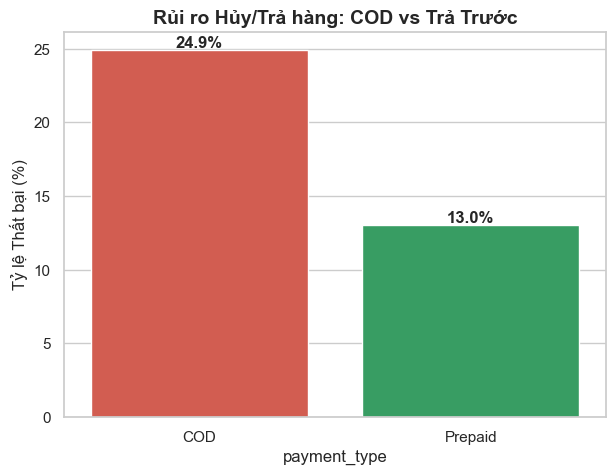

In [133]:
# Reset index để đưa Series về dạng DataFrame chuẩn (Tránh lỗi thư viện Seaborn mới)
# SỬ DỤNG ĐÚNG TÊN BIẾN: payment_fail_rate
df_plot1 = payment_fail_rate.reset_index()

# Đổi lại tên cột cho dễ gọi (payment_type và is_failed)
df_plot1.columns = ['payment_type', 'failed_rate']

# Vẽ Biểu đồ 1: COD vs Prepaid
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# Vẽ biểu đồ chuẩn với data=... và hue=...
ax = sns.barplot(
    data=df_plot1, 
    x='payment_type', 
    y='failed_rate', 
    hue='payment_type', 
    palette=["#e74c3c", "#27ae60"],
    legend=False
)

plt.title("Rủi ro Hủy/Trả hàng: COD vs Trả Trước", fontsize=14, fontweight='bold')
plt.ylabel("Tỷ lệ Thất bại (%)")

# Gắn label % lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 0.2), ha='center', fontweight='bold')

# Lưu và hiển thị
plt.savefig(os.path.join(FIG_DIR, "v1_comparison.png"), bbox_inches='tight', dpi=300)
plt.show() # Xuất sơ đồ ra màn hình Notebook

Vẽ Biểu đồ 2: Rủi ro COD theo Độ Tuổi


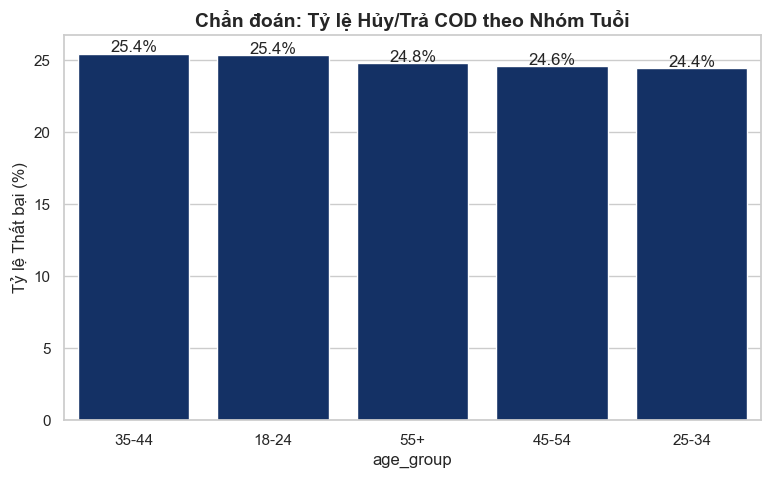

In [134]:
# Biểu đồ chẩn đoán độ tuổi
plt.figure(figsize=(9, 5))
ax2 = sns.barplot(x=cod_fail_age.index, y=cod_fail_age.values, color="#062D72", order=cod_fail_age.sort_values(ascending=False).index)
plt.title("Chẩn đoán: Tỷ lệ Hủy/Trả COD theo Nhóm Tuổi", fontsize=14, fontweight='bold')
plt.ylabel("Tỷ lệ Thất bại (%)")

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() + 0.1), ha='center')

plt.savefig(os.path.join(FIG_DIR, "v1_cod_age_diagnostic.png"), bbox_inches='tight', dpi=300)
plt.show() # Xuất sơ đồ ra màn hình Notebook